## Implementação Eficiente: Atualização Incremental `SIMPLE BANDIT`

> *Slides 11 e 26 — "Implementação Eficiente (Incremental)" e "Eficiência Computacional"*

**Problema:** Armazenar todo o histórico de recompensas para recalcular a média a cada passo gasta muita memória e é computacionalmente custoso $O(n)$.

**Solução:** Atualização **incremental** em $O(1)$ — atualizamos a estimativa passo a passo, sem guardar o histórico:

$$Q_{n+1} = Q_n + \frac{1}{n}\left[R_n - Q_n\right]$$

```
┌──────────┐      ┌──────┐      ┌────────────┐      ┌──────────────┐      ┌───────────┐
│Estimativa│ ───► │ Ação │ ───► │ Recompensa │ ───► │    Erro      │ ───► │   Nova    │
│  Atual   │      │      │      │   (R_n)    │      │ (R_n − Q_n)  │      │ Estimativa│
│  (Q_n)   │      │      │      │            │      │              │      │ (Q_{n+1}) │
└──────────┘      └──────┘      └────────────┘      └──────────────┘      └───────────┘
      ▲                                                                           │
      └───────────────────────────────────────────────────────────────────────────┘
```
**Conceito Geral:**

$$\text{Nova Estimativa} = \text{Velha Estimativa} + \underbrace{\frac{1}{n}}_{\text{Passo}} \times \underbrace{[R_n - Q_n]}_{\text{Erro (Target - Old)}}$$

Esta fórmula é **universal** no Aprendizado por Reforço. Ela aparece em TD-learning, Q-learning, Actor-Critic, etc. O "erro" $[R_n - Q_n]$ mede o quanto nossa previsão estava errada, e damos um passo proporcional a esse erro para corrigir.

No código Python, a atualização incremental fica em uma única linha:

```python
# Atualização incremental de Q[A]:
# Nova estimativa = Velha + (1/N[A]) * (Recompensa_recebida - Velha)
# Isso equivale à média amostral SEM precisar guardar histórico!
Q[A] += (1 / N[A]) * (R - Q[A])
```

## Não-Estacionariedade e Passo Constante $\alpha$ `TRACKING`

> *Slides 14 e 29 — "Quando o Mundo Muda: Não-Estacionariedade" e "Problemas Não-Estacionários"*

### O Problema

E se o valor real $q_*(a)$ **mudar com o tempo**? (Ex: um novo chef no restaurante mudou a qualidade da comida.)

**Falha da Média Simples:** A fórmula $Q_{n+1} = Q_n + \frac{1}{n}[R_n - Q_n]$ usa passo $\frac{1}{n}$ que **diminui** com o tempo. No início aprende rápido, mas com muitas amostras torna-se insensível a mudanças recentes — lembra demais do passado distante.

### A Solução: Passo Constante $\alpha$

Em vez de $\frac{1}{n}$, usamos um **passo constante** $\alpha \in (0, 1]$:

$$Q_{n+1} = Q_n + \alpha \left[R_n - Q_n\right]$$

Esta fórmula implementa uma **Média Ponderada Exponencial**: recompensas recentes recebem mais peso, recompensas antigas são gradualmente "esquecidas".

Expandindo a recursão:

$$Q_{n+1} = (1-\alpha)^n Q_1 + \sum_{i=1}^{n} \alpha(1-\alpha)^{n-i} R_i$$

O peso de $R_i$ decai exponencialmente com $(1-\alpha)^{n-i}$ — quanto mais antiga a recompensa, menor seu peso.

> **Legenda Figura (Slide 29):** Quando $q_*(a)$ salta abruptamente (linha sólida azul), a Média Padrão (linha tracejada amarela) demora muito para reagir. A Média Exponencial (linha sólida cinza) se adapta muito mais rapidamente à nova realidade.

**Escolha do hiperparâmetro:**
- $\alpha$ grande (ex: 0.9) → adapta-se rapidamente, mas é instável/ruidoso
- $\alpha$ pequeno (ex: 0.01) → mais estável, mas lento para se adaptar
- $\alpha = \frac{1}{n}$ → média simples (boa para ambientes estacionários)

### 11.1 Implementação: `tracking_bandit`

> *Baseado em Sutton & Barto 2018, Cap. 2.5 — implementação de Marcin Bogdanski*

O `tracking_bandit` é idêntico ao `simple_bandit` com **duas diferenças estruturais**: usa passo constante `alpha` no lugar de `1/N[A]`, e aceita um valor de inicialização `Q_init` configurável. Isso o torna mais versátil — permite tanto a abordagem realista (Q_init=0) quanto a otimista (Q_init=5), ambas com rastreamento de ambientes não-estacionários.

```python
def tracking_bandit(env, nb, eps, alpha, Q_init):
    """
    Tracking Bandit — Sutton & Barto 2018, Seção 2.5, equação (2.5).

    Diferenças em relação ao simple_bandit:
    ----------------------------------------
    1) Passo constante alpha (não 1/N): dá mais peso a recompensas recentes.
       Ideal para ambientes onde q*(a) pode mudar com o tempo.
    2) Q_init configurável: permite testar inicialização realista (Q_init=0)
       ou otimista (Q_init=5) com o mesmo código.

    Parâmetros:
    -----------
    env    : BanditEnv  — ambiente do bandido
    nb     : int        — número de passos
    eps    : float      — probabilidade de exploração ε ∈ [0, 1]
    alpha  : float      — passo constante α ∈ (0, 1] para atualização
    Q_init : float      — valor inicial de todas as estimativas Q

    Retorna:
    --------
    Q      : ndarray (env.size,) — estimativas finais
    hist_A : ndarray (nb,)       — histórico de ações
    hist_R : ndarray (nb,)       — histórico de recompensas
    """
    # --- Histórico para análise posterior ---
    hist_A = []
    hist_R = []

    # --- Inicialização das estimativas com Q_init ---
    # Q_init=0  → "realista": começa sem viés, aprende do zero
    # Q_init=5  → "otimista": força exploração inicial (ver Seção 12)
    Q = np.zeros(env.size) + Q_init

    for _ in range(nb):
        # --- Seleção de Ação: ε-greedy (idêntico ao simple_bandit) ---
        if np.random.rand() > eps:
            A = argmax_rand(Q)              # explotação: escolhe o melhor estimado
        else:
            A = np.random.randint(env.size) # exploração: escolhe aleatoriamente

        # --- Interação com o Ambiente ---
        R = env.step(A)   # recompensa estocástica: R ~ N(q*(A), 1)

        # --- Atualização com Passo Constante α (a diferença chave!) ---
        # Simple Bandit:   Q[A] += (1/N[A]) * (R - Q[A])  → passo DIMINUI com n
        # Tracking Bandit: Q[A] += alpha    * (R - Q[A])  → passo CONSTANTE
        #
        # O passo constante implementa uma média ponderada exponencial:
        # Q_{n+1} = (1-α)^n * Q_1 + Σ α*(1-α)^(n-i) * R_i
        # Recompensas antigas têm peso (1-α)^k → se α=0.1, após 10 passos
        # o peso cai para (0.9)^10 ≈ 0.35; após 50 passos cai para 0.005.
        Q[A] += alpha * (R - Q[A])

        # --- Registro do histórico ---
        hist_A.append(A)
        hist_R.append(R)

    return Q, np.array(hist_A), np.array(hist_R)
```

# Importações

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Função argmax_rand

In [2]:
def argmax_rand(arr):
    """
    Retorna o índice do valor máximo do array,
    quebrando empates de forma ALEATÓRIA.

    Por que isso importa?
    np.argmax() sempre retorna o PRIMEIRO índice em caso de empate.
    No início, Q = [0, 0, 0, ...] — todos empatados!
    Se não quebrarmos empates aleatoriamente, o agente sempre
    escolheria o braço 0 primeiro, introduzindo um viés injusto.
    """
    return np.random.choice(np.flatnonzero(arr == arr.max()))

# Ambiente k Armed bandit k = 10

In [3]:
class BanditEnv:
    def __init__(self):
        """
        Ambiente testbed de 10 braços — ver Sutton & Barto, seção 2.3.
        Cada braço 'a' tem um valor real q*(a) fixo (a 'verdade oculta').
        As recompensas são amostradas de N(q*(a), 1), ou seja:
        - Média: q*(a)  →  o que queremos estimar com Q_t(a)
        - Desvio padrão: 1  →  o ruído que dificulta o aprendizado
        """
        self.size = 10  # número de braços (ações disponíveis)

        # Valores reais q*(a) de cada braço — desconhecidos pelo agente!
        # Foram definidos manualmente para reproduzir a Figura 2.1 do livro.
        self.means = np.array([0.25, -0.75, 1.5, 0.5, 1.25,
                               -1.5, -0.25, -1, 0.75, -0.5])

    def step(self, action):
        """
        Executa uma ação e retorna a recompensa estocástica.
        R_t ~ N(q*(action), 1)
        O agente vê apenas R_t — NÃO tem acesso direto a q*(action).
        """
        return np.random.normal(loc=self.means[action])

# Implementação Atualização Incremental `simple_bandit`

In [4]:
def simple_bandit(env, nb, eps):
    """
    Algoritmo Simple Bandit — Sutton & Barto 2018, Seção 2.4.

    Parâmetros:
    -----------
    env : BanditEnv
        O ambiente do bandido (contém as distribuições de recompensa)
    nb : int
        Número de passos (bandit pulls) a executar
    eps : float
        Probabilidade de exploração ε ∈ [0, 1]
        eps=0   → greedy puro (sem exploração)
        eps=0.1 → explora 10% das vezes aleatoriamente
        eps=1   → totalmente aleatório (não recomendado)

    Retorna:
    --------
    Q : ndarray, shape (env.size,)
        Estimativas finais de Q_t(a) para cada braço
    hist_A : ndarray, shape (nb,)
        Histórico de ações escolhidas em cada passo
    hist_R : ndarray, shape (nb,)
        Histórico de recompensas recebidas em cada passo
    """
    # --- Histórico para análise posterior ---
    hist_A = []   # registra qual ação foi escolhida em cada passo
    hist_R = []   # registra a recompensa recebida em cada passo

    # --- Inicialização das estimativas ---
    Q = np.zeros(env.size)   # Q[a] = estimativa de q*(a), inicializada em 0
    N = np.zeros(env.size)   # N[a] = contagem de vezes que o braço 'a' foi puxado

    for _ in range(nb):
        # --- Seleção de Ação: ε-greedy ---
        if np.random.rand() > eps:
            # Com probabilidade (1-ε): EXPLOTAÇÃO — escolhe o melhor braço estimado
            # argmax_rand quebra empates aleatoriamente (importante no início!)
            A = argmax_rand(Q)
        else:
            # Com probabilidade ε: EXPLORAÇÃO — escolhe um braço aleatório
            A = np.random.randint(env.size)

        # --- Interação com o Ambiente ---
        R = env.step(A)   # recebe recompensa R_t ~ N(q*(A), 1)

        # --- Atualização Incremental (fórmula central!) ---
        N[A] += 1          # incrementa o contador deste braço
        # Nova estimativa = Velha + (1/N) * (Recompensa - Velha)
        # Equivale à média amostral, mas sem guardar histórico: O(1) memória!
        Q[A] += (1 / N[A]) * (R - Q[A])

        # --- Registro do histórico ---
        hist_A.append(A)
        hist_R.append(R)

    return Q, np.array(hist_A), np.array(hist_R)

# Implementação passo constante `tracking_bandit`

In [5]:
def tracking_bandit(env, nb, eps, alpha, Q_init):
    """
    Tracking Bandit — Sutton & Barto 2018, Seção 2.5, equação (2.5).

    Diferenças em relação ao simple_bandit:
    ----------------------------------------
    1) Passo constante alpha (não 1/N): dá mais peso a recompensas recentes.
       Ideal para ambientes onde q*(a) pode mudar com o tempo.
    2) Q_init configurável: permite testar inicialização realista (Q_init=0)
       ou otimista (Q_init=5) com o mesmo código.

    Parâmetros:
    -----------
    env    : BanditEnv  — ambiente do bandido
    nb     : int        — número de passos
    eps    : float      — probabilidade de exploração ε ∈ [0, 1]
    alpha  : float      — passo constante α ∈ (0, 1] para atualização
    Q_init : float      — valor inicial de todas as estimativas Q

    Retorna:
    --------
    Q      : ndarray (env.size,) — estimativas finais
    hist_A : ndarray (nb,)       — histórico de ações
    hist_R : ndarray (nb,)       — histórico de recompensas
    """
    # --- Histórico para análise posterior ---
    hist_A = []
    hist_R = []

    # --- Inicialização das estimativas com Q_init ---
    # Q_init=0  → "realista": começa sem viés, aprende do zero
    # Q_init=5  → "otimista": força exploração inicial (ver Seção 12)
    Q = np.zeros(env.size) + Q_init

    for _ in range(nb):
        # --- Seleção de Ação: ε-greedy (idêntico ao simple_bandit) ---
        if np.random.rand() > eps:
            A = argmax_rand(Q)              # explotação: escolhe o melhor estimado
        else:
            A = np.random.randint(env.size) # exploração: escolhe aleatoriamente

        # --- Interação com o Ambiente ---
        R = env.step(A)   # recompensa estocástica: R ~ N(q*(A), 1)

        # --- Atualização com Passo Constante α (a diferença chave!) ---
        # Simple Bandit:   Q[A] += (1/N[A]) * (R - Q[A])  → passo DIMINUI com n
        # Tracking Bandit: Q[A] += alpha    * (R - Q[A])  → passo CONSTANTE
        #
        # O passo constante implementa uma média ponderada exponencial:
        # Q_{n+1} = (1-α)^n * Q_1 + Σ α*(1-α)^(n-i) * R_i
        # Recompensas antigas têm peso (1-α)^k → se α=0.1, após 10 passos
        # o peso cai para (0.9)^10 ≈ 0.35; após 50 passos cai para 0.005.
        Q[A] += alpha * (R - Q[A])

        # --- Registro do histórico ---
        hist_A.append(A)
        hist_R.append(R)

    return Q, np.array(hist_A), np.array(hist_R)

# Execução do do k-Armed Bandits

1. Neste execução iremos usar a classe de base com 10 distribuições e verificar se o agente consegue encontrar a distribuição ótima
2. Iremos usar três agentes `tracking_bandit`:
- o primeiro agente é **greedy** e de atualização incremental (simple_bandit) possui os seguintes paramêtros $\epsilon$ = 0.0, 
- o segundo agente é **$\epsilon$-greedy de passo constante (tracking_bandit) e possui os seguintes paramêtros $\epsilon$ = 0.1, $\alpha$ 0.1, e `Q_init = 4.0` otimista
- o segundo agente é **$\epsilon$-greedy de passo constante (tracking_bandit) e possui os seguintes paramêtros $\epsilon$ = 0.1, $\alpha$ 0.01, e `Q_init = 0.0`
3. A seguir verificamos qual a % de melhor escolha para cada agentee calculamos a média dessas escolhas e plotamos os gráficos

In [6]:
env = BanditEnv()

# Listas para armazenar históricos de todas as execuções
runs_ep0_A,   runs_ep0_R   = [], []   # eps=0    → greedy puro
runs_ep01_A,  runs_ep01_R  = [], []   # eps=0.0  → greedy puro Incialização Otimista
runs_ep001_A, runs_ep001_R = [], []   # eps=0.01 → explora 1%

print('v' + ' ' * 18 + 'v')   # barra de progresso simples

for i in range(2000):   # 2000 runs independentes
    # Cada run: 1000 passos com cada estratégia no MESMO ambiente
    _, hist_A, hist_R = simple_bandit(env, nb=1000, eps=0)
    runs_ep0_A.append(hist_A);   runs_ep0_R.append(hist_R)

    _, hist_A, hist_R = tracking_bandit(env, nb=1000, eps=0.0, alpha=0.1, Q_init=2.0)
    runs_ep01_A.append(hist_A);  runs_ep01_R.append(hist_R)

    _, hist_A, hist_R = tracking_bandit(env, nb=1000, eps=0.01, alpha=0.1, Q_init=0)
    runs_ep001_A.append(hist_A); runs_ep001_R.append(hist_R)

    if i % 100 == 0:
        print('.', end='')   # progresso a cada 100 runs

# Converte listas para arrays numpy para operações vetorizadas
runs_ep0_A,   runs_ep0_R   = np.array(runs_ep0_A),   np.array(runs_ep0_R)
runs_ep01_A,  runs_ep01_R  = np.array(runs_ep01_A),  np.array(runs_ep01_R)
runs_ep001_A, runs_ep001_R = np.array(runs_ep001_A), np.array(runs_ep001_R)

v                  v
....................

In [7]:
print(env.size)
print(env.means)

10
[ 0.25 -0.75  1.5   0.5   1.25 -1.5  -0.25 -1.    0.75 -0.5 ]


In [8]:
### 15.3 Calculando Métricas de Desempenho


# --- Métrica 1: Recompensa Média por Passo ---
# Média sobre os 2000 runs para cada passo de tempo t
avg_ep0_R   = np.average(runs_ep0_R,   axis=0)   # shape: (1000,)
avg_ep01_R  = np.average(runs_ep01_R,  axis=0)
avg_ep001_R = np.average(runs_ep001_R, axis=0)

# --- Métrica 2: % de Ação Ótima ---
# Qual braço tem o maior q*(a)? Esse é o braço "ótimo"
max_A = np.argmax(env.means)   # índice do braço ótimo

# Para cada passo, qual fração dos 2000 runs escolheu o braço ótimo?
opt_ep0_A   = np.average(runs_ep0_A   == max_A, axis=0)   # shape: (1000,)
opt_ep01_A  = np.average(runs_ep01_A  == max_A, axis=0)
opt_ep001_A = np.average(runs_ep001_A == max_A, axis=0)

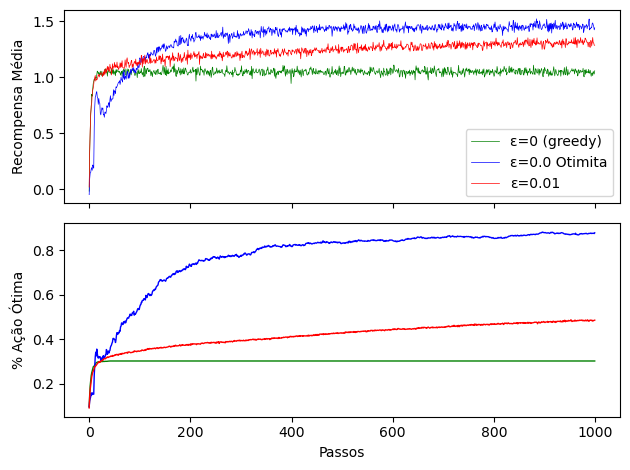

In [9]:
### 15.4 Reproduzindo a Figura 2.2


fig = plt.figure()

# --- Painel Superior: Recompensa Média ---
ax = fig.add_subplot(211)
ax.plot(avg_ep0_R,   linewidth=0.5, color='green', label='ε=0 (greedy)')
ax.plot(avg_ep01_R,  linewidth=0.5, color='blue',  label='ε=0.0 Otimista')
ax.plot(avg_ep001_R, linewidth=0.5, color='red',   label='ε=0.01')
ax.set_ylabel('Recompensa Média')
ax.xaxis.set_ticklabels([])   # remove rótulos do eixo x no painel superior
ax.legend()

# --- Painel Inferior: % de Ação Ótima ---
ax = fig.add_subplot(212)
ax.plot(opt_ep0_A,   linewidth=1., color='green', label='ε=0 (greedy)')
ax.plot(opt_ep01_A,  linewidth=1., color='blue',  label='ε=0.1')
ax.plot(opt_ep001_A, linewidth=1., color='red',   label='ε=0.01')
ax.set_xlabel('Passos')
ax.set_ylabel('% Ação Ótima')

plt.tight_layout()
#plt.savefig('assets/fig_0202.png')
plt.show()

# Exercício Resolvido

1. Neste execução iremos usar a classe de base com 10 distribuições e verificar se o agente consegue encontrar a distribuição ótima, porém iremos mudar o ambiente para apenas trê distribuições com médias `[ -0.75,  0.5,   2.5, -1.5, 0.75 ]`
2. Iremos usar um agente `simple_bandit` e dois agentes `tracking_bandit`:
- o primeiro agente é **greedy** e de atualização incremental (simple_bandit) possui os seguintes paramêtros $\epsilon$ = 0.0, 
- o segundo agente é **$\epsilon$-greedy de passo constante (tracking_bandit) e possui os seguintes paramêtros $\epsilon$ = 0.1, $\alpha$ 0.1, e `Q_init = 3.0` otimista
- o segundo agente é **$\epsilon$-greedy de passo constante (tracking_bandit) e possui os seguintes paramêtros $\epsilon$ = 0.1, $\alpha$ 0.01, e `Q_init = 0.0`
3. A seguir verificamos qual a % de melhor escolha para cada agentee calculamos a média dessas escolhas e plotamos os gráficos

In [40]:
env = BanditEnv()
env.size=5
env.means = [ -0.75,  0.5,   2.5, -1.5, 0.75 ]

# Listas para armazenar históricos de todas as execuções
runs_ep0_A,   runs_ep0_R   = [], []   # eps=0    → greedy puro
runs_ep0_O_A,  runs_ep0_O_R  = [], []   # eps=0.0  → greedy puro Incialização Otimista
runs_ep001_A, runs_ep001_R = [], []   # eps=0.01 → explora 1%

print('v' + ' ' * 18 + 'v')   # barra de progresso simples

for i in range(2000):   # 2000 runs independentes
    # Cada run: 1000 passos com cada estratégia no MESMO ambiente
    _, hist_A, hist_R = simple_bandit(env, nb=1000, eps=0.1)
    runs_ep0_A.append(hist_A);   runs_ep0_R.append(hist_R)

    _, hist_A, hist_R = tracking_bandit(env, nb=1000, eps=0.0, alpha=0.1, Q_init=3.0)
    runs_ep0_O_A.append(hist_A);  runs_ep0_O_R.append(hist_R)

    _, hist_A, hist_R = tracking_bandit(env, nb=1000, eps=0.01, alpha=0.1, Q_init=0)
    runs_ep001_A.append(hist_A); runs_ep001_R.append(hist_R)

    if i % 100 == 0:
        print('.', end='')   # progresso a cada 100 runs

# Converte listas para arrays numpy para operações vetorizadas
runs_ep0_A,   runs_ep0_R   = np.array(runs_ep0_A),   np.array(runs_ep0_R)
runs_ep0_O_A,  runs_ep0_O_R  = np.array(runs_ep0_O_A),  np.array(runs_ep0_O_R)
runs_ep001_A, runs_ep001_R = np.array(runs_ep001_A), np.array(runs_ep001_R)

v                  v
....................

In [41]:
### 15.3 Calculando Métricas de Desempenho


# --- Métrica 1: Recompensa Média por Passo ---
# Média sobre os 2000 runs para cada passo de tempo t
avg_ep0_R   = np.average(runs_ep0_R,   axis=0)   # shape: (1000,)
avg_ep_O_R  = np.average(runs_ep_O_R,  axis=0)
avg_ep001_R = np.average(runs_ep001_R, axis=0)

# --- Métrica 2: % de Ação Ótima ---
# Qual braço tem o maior q*(a)? Esse é o braço "ótimo"
max_A = np.argmax(env.means)   # índice do braço ótimo

# Para cada passo, qual fração dos 2000 runs escolheu o braço ótimo?
opt_ep0_A   = np.average(runs_ep0_A   == max_A, axis=0)   # shape: (1000,)
opt_ep_O_A  = np.average(runs_ep0_O_A  == max_A, axis=0)
opt_ep001_A = np.average(runs_ep001_A == max_A, axis=0)

In [42]:
print(max_A)
print(env.size)
print(env.means)

2
5
[-0.75, 0.5, 2.5, -1.5, 0.75]


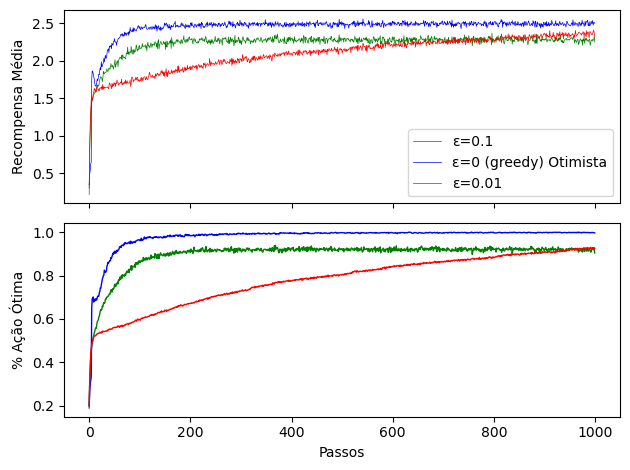

In [43]:
### 15.4 Reproduzindo a Figura 2.2


fig = plt.figure()

# --- Painel Superior: Recompensa Média ---
ax = fig.add_subplot(211)
ax.plot(avg_ep0_R,   linewidth=0.5, color='green', label='ε=0.1')
ax.plot(avg_ep_O_R,  linewidth=0.5, color='blue',  label='ε=0 (greedy) Otimista')
ax.plot(avg_ep001_R, linewidth=0.5, color='red',   label='ε=0.01')
ax.set_ylabel('Recompensa Média')
ax.xaxis.set_ticklabels([])   # remove rótulos do eixo x no painel superior
ax.legend()

# --- Painel Inferior: % de Ação Ótima ---
ax = fig.add_subplot(212)
ax.plot(opt_ep0_A,   linewidth=1., color='green', label='ε=0 (greedy)')
ax.plot(opt_ep_O_A,  linewidth=1., color='blue',  label='ε=0 (greedy) Otimista')
ax.plot(opt_ep001_A, linewidth=1., color='red',   label='ε=0.01')
ax.set_xlabel('Passos')
ax.set_ylabel('% Ação Ótima')

plt.tight_layout()
#plt.savefig('assets/fig_0202.png')
plt.show()